# Netflix Recommendation System

## Project Category
Recommendation Systems

---

## Objective

The objective of this project is to build a movie recommendation system using machine learning and similarity techniques.

This project aims to:
- analyze movie datasets,
- identify similar movies,
- recommend movies to users,
- apply recommendation algorithms,
- evaluate recommendation logic.

---

## Dataset Information

The dataset contains information about Netflix movies and TV shows such as:

- Title
- Genre
- Description
- Cast
- Director
- Release Year
- Rating
- Duration

The recommendation system will use content-based filtering techniques to recommend similar movies.

---

## Algorithms and Techniques Used

- Content-Based Filtering
- TF-IDF Vectorization
- Cosine Similarity
- Text Feature Engineering

---

## Project Workflow

1. Data Understanding
2. Data Cleaning
3. Feature Engineering
4. TF-IDF Vectorization
5. Cosine Similarity Calculation
6. Recommendation Function
7. Recommendation Results
8. Conclusion

In [1]:
from google.colab import files

uploaded = files.upload()

Saving netflix_titles.csv to netflix_titles.csv


In [2]:
import pandas as pd

df = pd.read_csv("netflix_titles.csv")

df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [3]:
df.tail()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,s8804,TV Show,Zombie Dumb,NaN,NaN,NaN,"July 1, 2019",2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."
8806,s8807,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,"March 2, 2019",2015,TV-14,111 min,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...


In [4]:
#DataSet OverView
print("Dataset Shape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

Dataset Shape: (8807, 12)

Columns:
Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

Data Types:
show_id         object
type            object
title           object
director        object
cast            object
country         object
date_added      object
release_year     int64
rating          object
duration        object
listed_in       object
description     object
dtype: object

Missing Values:
show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

Duplicate Rows:
0


In [5]:
df["director"] = df["director"].fillna("")

df["cast"] = df["cast"].fillna("")

df["country"] = df["country"].fillna("")

df["rating"] = df["rating"].fillna("")

df["duration"] = df["duration"].fillna("")

In [6]:
df["content"] = (

    df["listed_in"] + " " +

    df["description"] + " " +

    df["director"] + " " +

    df["cast"])

In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    stop_words="english")

tfidf_matrix = tfidf.fit_transform(
    df["content"])

In [8]:
from sklearn.metrics.pairwise import cosine_similarity

cosine_sim = cosine_similarity(tfidf_matrix,tfidf_matrix)

In [10]:
indices = pd.Series( df.index,index=df["title"]).drop_duplicates()

### Recommendation Function

In [11]:
def recommend_movies(title, cosine_sim=cosine_sim):

    idx = indices[title]

    sim_scores = list(
        enumerate(cosine_sim[idx]))

    sim_scores = sorted(
        sim_scores,
        key=lambda x: x[1],
        reverse=True)

    sim_scores = sim_scores[1:11]

    movie_indices = [i[0] for i in sim_scores]

    return df["title"].iloc[movie_indices]

In [12]:
recommend_movies("Stranger Things")

,title
5200,Beyond Stranger Things
1127,Prank Encounters
2190,The Umbrella Academy
6167,Anjaan: Special Crimes Unit
3398,Eli
1240,Safe Haven
1396,Homefront
4809,Kiss Me First
2600,Good Witch
6703,Equilibrium


In [13]:
recommendations = recommend_movies("Stranger Things")

recommendations_df = pd.DataFrame({"Recommended Movies":recommendations.values})

recommendations_df

,Recommended Movies
0,Beyond Stranger Things
1,Prank Encounters
2,The Umbrella Academy
3,Anjaan: Special Crimes Unit
4,Eli
5,Safe Haven
6,Homefront
7,Kiss Me First
8,Good Witch
9,Equilibrium


In [14]:
recommend_movies("Breaking Bad")

,title
2931,Better Call Saul
8505,The Show
355,The Lincoln Lawyer
5606,Girlfriend's Day
5352,"Have You Ever Fallen in Love, Miss Jiang?"
6841,Get Shorty
5885,W/ Bob & David
2606,Extracurricular
5703,Refresh Man
430,Sexy Beasts


In [15]:
recommend_movies("Narcos")

,title
3298,Wild District
6672,El Cartel
1268,El final del paraíso
7258,La Viuda Negra
2134,The Great Heist
6652,Dueños del paraíso
2921,Narcos: Mexico
1270,Sin senos sí hay paraíso
3212,La Reina del Sur
7463,Miss Dynamite


In [16]:
recommend_movies("The Witcher")

,title
2058,The Witcher: A Look Inside the Episodes
2095,Making The Witcher
1166,The Irregulars
7870,Ripper Street
4501,Wanderlust
1740,Love & Anarchy
1816,Tremors: Shrieker Island
5464,The Day Will Come
8490,The Road to Calvary
7004,Hot Property


In [18]:
def recommend_movies_with_scores(
    title,
    cosine_sim=cosine_sim):

    idx = indices[title]

    sim_scores = list(
        enumerate(cosine_sim[idx]))

    sim_scores = sorted(
        sim_scores,
        key=lambda x: x[1],
        reverse=True)

    sim_scores = sim_scores[1:11]

    movie_indices = [i[0] for i in sim_scores ]

    scores = [i[1] for i in sim_scores]

    recommendations = pd.DataFrame({

        "Movie":
            df["title"].iloc[movie_indices].values,

        "Similarity Score":
            scores})

    return recommendations

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

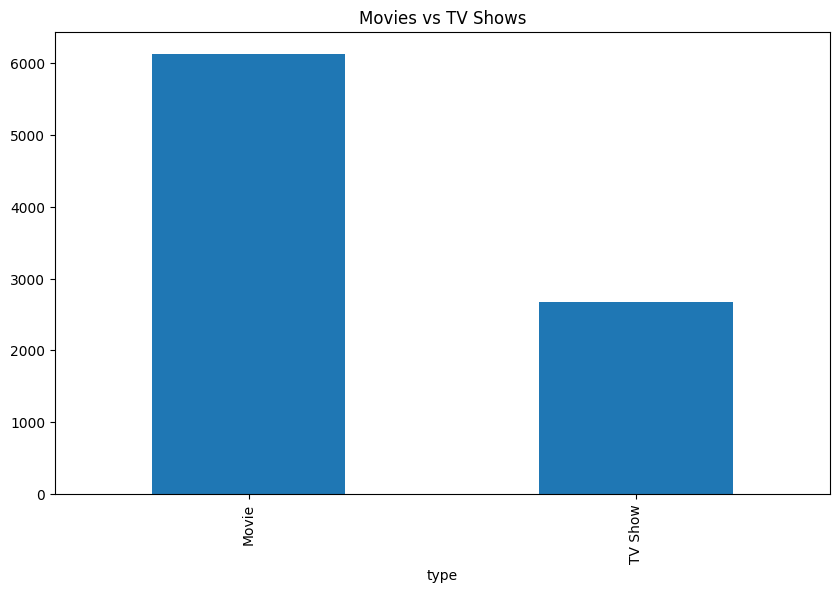

In [22]:
plt.figure(figsize=(10,6))

df["type"].value_counts().plot(kind="bar")

plt.title("Movies vs TV Shows")

plt.show()

In [23]:
from collections import Counter

genres = ",".join(df["listed_in"]).split(",")

genre_counts = Counter(genres)

top_genres = genre_counts.most_common(10)

genre_df = pd.DataFrame(
    top_genres,
    columns=["Genre", "Count"])

genre_df

,Genre,Count
0,International Movies,2624
1,Dramas,1600
2,Comedies,1210
3,Action & Adventure,859
4,Documentaries,829
5,Dramas,827
6,International TV Shows,774
7,Independent Movies,736
8,TV Dramas,696
9,Romantic Movies,613


/tmp/ipykernel_567/1545601885.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


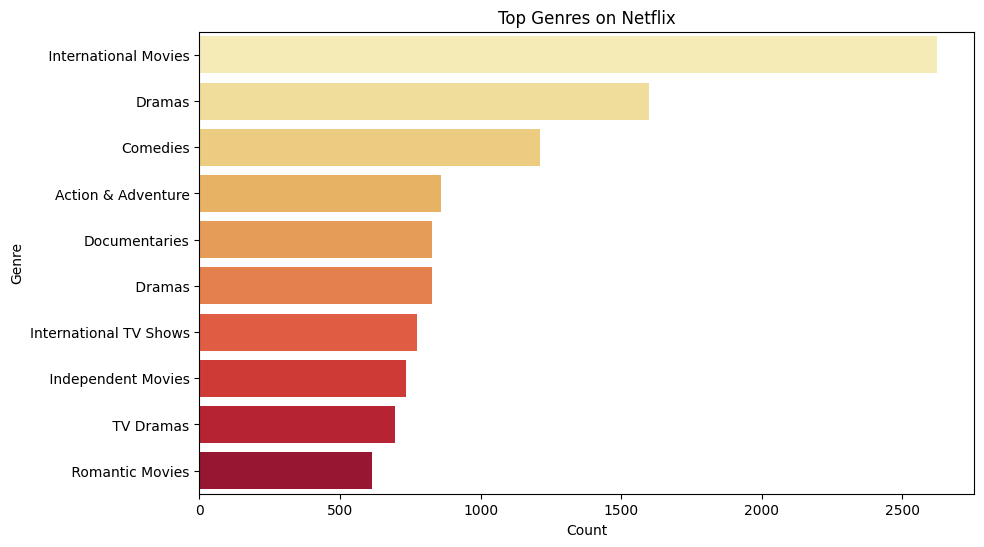

In [24]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=genre_df,
    x="Count",
    y="Genre",
    palette="YlOrRd")

plt.title("Top Genres on Netflix")

plt.show()

In [26]:
recommend_movies_with_scores("Narcos")

,Movie,Similarity Score
0,Wild District,0.196491
1,El Cartel,0.163907
2,El final del paraíso,0.153105
3,La Viuda Negra,0.148565
4,The Great Heist,0.147369
5,Dueños del paraíso,0.142978
6,Narcos: Mexico,0.138925
7,Sin senos sí hay paraíso,0.136729
8,La Reina del Sur,0.131763
9,Miss Dynamite,0.129691


In [27]:
recommend_movies_with_scores("The Witcher")

,Movie,Similarity Score
0,The Witcher: A Look Inside the Episodes,0.429692
1,Making The Witcher,0.337383
2,The Irregulars,0.114361
3,Ripper Street,0.107321
4,Wanderlust,0.104110
5,Love & Anarchy,0.081534
6,Tremors: Shrieker Island,0.079394
7,The Day Will Come,0.076883
8,The Road to Calvary,0.076177
9,Hot Property,0.076055


In [28]:
movie_name = "Narcos"

recommend_movies_with_scores( movie_name)

,Movie,Similarity Score
0,Wild District,0.196491
1,El Cartel,0.163907
2,El final del paraíso,0.153105
3,La Viuda Negra,0.148565
4,The Great Heist,0.147369
5,Dueños del paraíso,0.142978
6,Narcos: Mexico,0.138925
7,Sin senos sí hay paraíso,0.136729
8,La Reina del Sur,0.131763
9,Miss Dynamite,0.129691


## Conclusion

A Netflix recommendation system was successfully developed using content-based filtering techniques.

The project utilized:
- TF-IDF vectorization,
- cosine similarity,
- feature engineering,
- and NLP-based text analysis

to recommend similar movies and TV shows.

The recommendation engine analyzed movie genres, descriptions, cast members, and directors to identify content similarity between titles.

The system successfully generated meaningful recommendations for various Netflix titles such as:
- Narcos,
- Stranger Things,
- The Witcher,
- and Breaking Bad.

The recommendation results demonstrated that cosine similarity and NLP techniques can effectively identify related content based on textual features.

This project provided practical experience in:
- recommendation systems,
- natural language processing,
- similarity metrics,
- and machine learning-based content analysis.